# Wine Quality Prediction-Machine Learning

## 📌 Introduction
Ce projet vise à prédire la qualité du vin en utilisant des modèles de Machine Learning.

##  Chargement des données

In [21]:
import pandas as pd

df = pd.read_csv("winequality-red.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


##  Exploration des données

In [22]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

(1599, 12)
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   f

##  Vérification des valeurs manquantes

In [23]:
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


## 📈 Visualisation des données

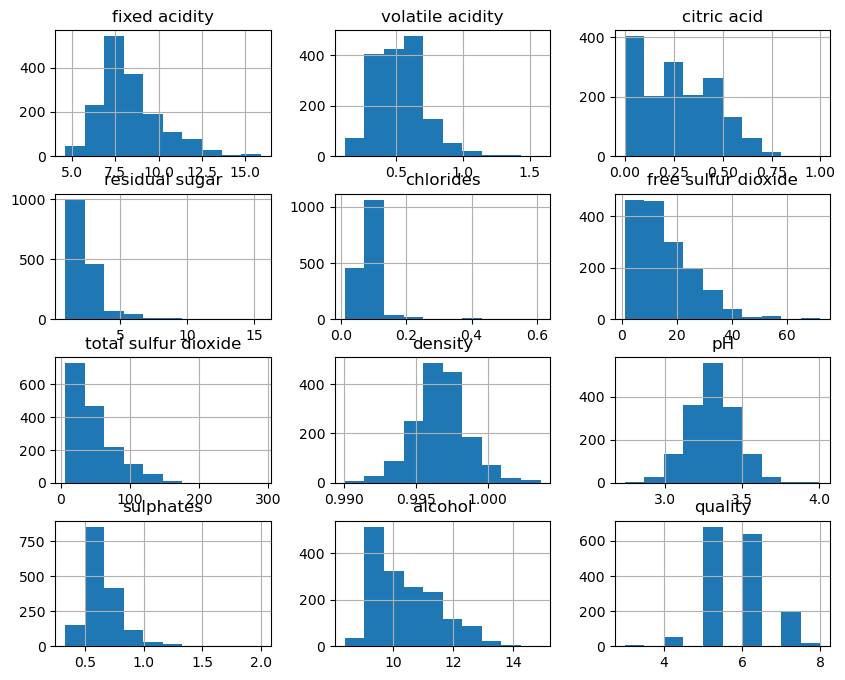

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# histogrammes
df.hist(figsize=(10,8))
plt.show()

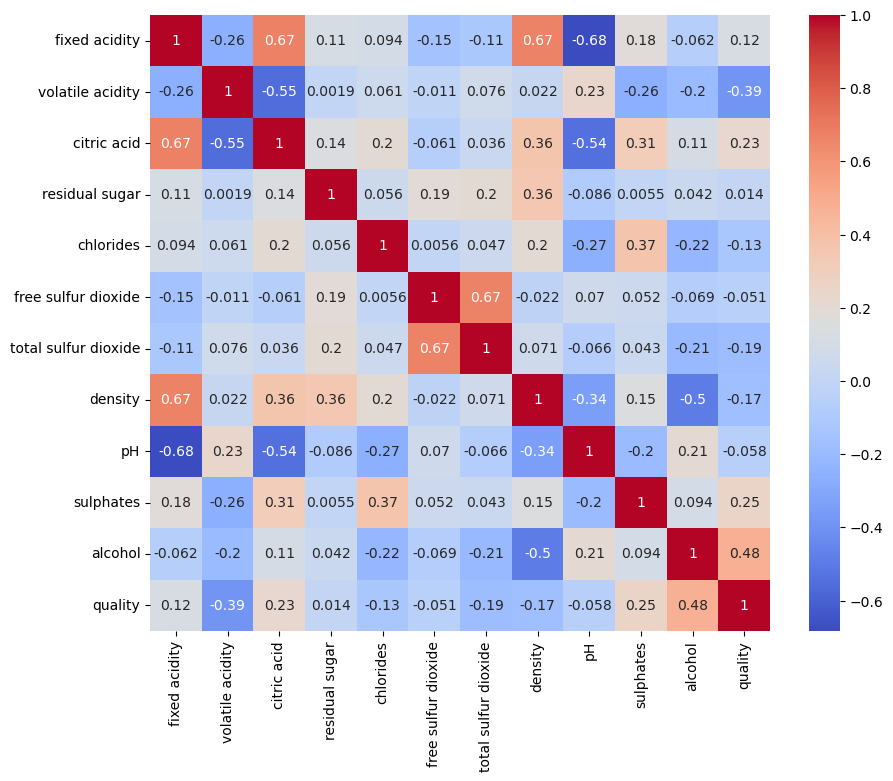

In [25]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

##  Pré-traitement des données

## Création de la variable de classification

In [26]:
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

df[['quality', 'quality_label']].head()

,quality,quality_label
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0


# PARTIE I : RÉGRESSION

## Préparation des données pour la régression

In [27]:
X_reg = df.drop(['quality', 'quality_label'], axis=1)

y_reg = df['quality']

##  Séparation des données (Train/Test)

In [28]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print(X_train_reg.shape, X_test_reg.shape)

(1279, 11) (320, 11)


## Linear Regression

In [29]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_reg, y_train_reg)

y_pred_reg = lr.predict(X_test_reg)

print(y_pred_reg[:10])

[5.34666441 5.05631345 5.66446972 5.46451484 5.72518476 5.27928659
 5.03421667 5.12623347 5.74534288 5.68665032]


## Évaluation de la régression

In [30]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test_reg, y_pred_reg)

r2 = r2_score(y_test_reg, y_pred_reg)

print("MSE :", mse)

print("R2 Score :", r2)

MSE : 0.3900251439639545
R2 Score : 0.40318034127962254


# PARTIE II : CLASSIFICATION

## Préparation des données

In [31]:
X = df.drop(['quality', 'quality_label'], axis=1)

y = df['quality_label']

### Standardisation des données

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Séparation des données (Train/Test)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(1279, 11) (320, 11)


### Logistic Regression

In [34]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

acc_log = model.score(X_test, y_test)

print("Accuracy Logistic Regression :", acc_log)

Accuracy Logistic Regression : 0.865625


### K-Nearest Neighbors (KNN)

In [35]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

acc_knn = knn.score(X_test, y_test)

print("Accuracy KNN :", acc_knn)

Accuracy KNN : 0.878125


### Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

acc_rf = rf.score(X_test, y_test)

print("Accuracy Random Forest :", acc_rf)

Accuracy Random Forest : 0.90625


##  Comparaison des modèles

In [37]:
print("Logistic Regression :", acc_log)

print("KNN :", acc_knn)

print("Random Forest :", acc_rf)

Logistic Regression : 0.865625
KNN : 0.878125
Random Forest : 0.90625


## Visualisation des résultats

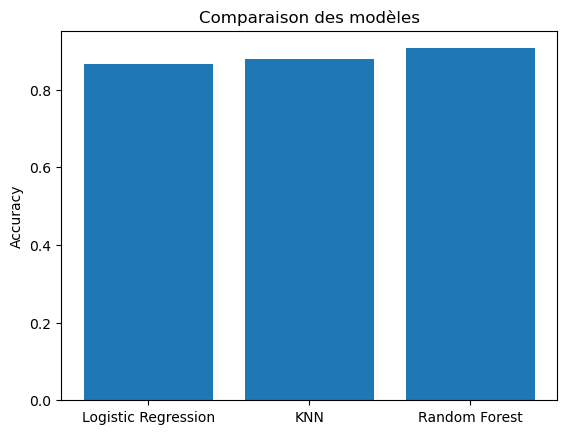

In [38]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'KNN', 'Random Forest']

scores = [acc_log, acc_knn, acc_rf]

plt.bar(models, scores)

plt.ylabel("Accuracy")

plt.title("Comparaison des modèles")

plt.show()

##  Matrice de confusion et rapport de classification

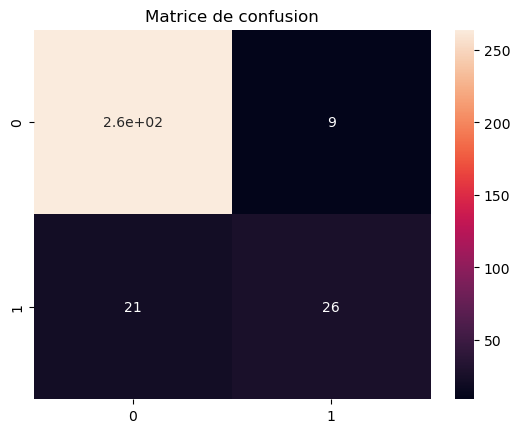

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       273
           1       0.74      0.55      0.63        47

    accuracy                           0.91       320
   macro avg       0.83      0.76      0.79       320
weighted avg       0.90      0.91      0.90       320



In [39]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True)

plt.title("Matrice de confusion")

plt.show()

print(classification_report(y_test, y_pred))

# PARTIE III : CLUSTERING

## Clustering avec KMeans

In [40]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters

### Visualisation des clusters

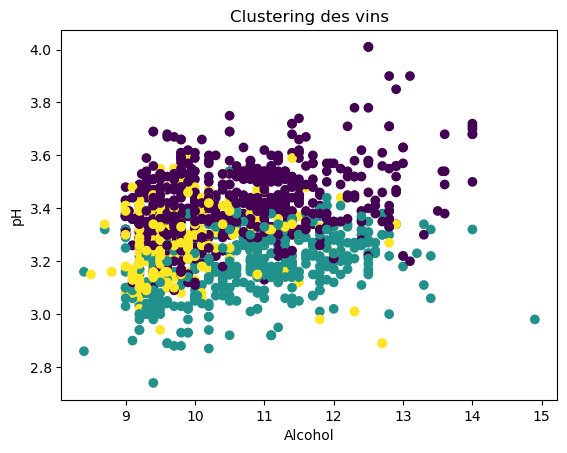

In [41]:
plt.scatter(df['alcohol'], df['pH'], c=df['cluster'])

plt.xlabel("Alcohol")

plt.ylabel("pH")

plt.title("Clustering des vins")

plt.show()

##  Conclusion
Le modèle Random Forest a donné les meilleures performances avec une accuracy de 90%.
